In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/waddahali/lifestyle-weight-tracker/lifestyle weight tracker.csv


In [2]:
# reading/assigning the training dataset
df = pd.read_csv('/kaggle/input/datasets/waddahali/lifestyle-weight-tracker/lifestyle weight tracker.csv')
# identifying the contributing factors
df.columns

Index(['User_ID', 'Age', 'Gender', 'Height_cm', 'Initial_Weight_kg',
       'Stress_Level', 'Sleep_Hours', 'Caffeine_mg', 'Calories_Consumed',
       'Protein_g', 'Carbs_g', 'Fat_g', 'Steps', 'Workout_Type',
       'Workout_Intensity', 'Temp_C', 'Weight_Change', 'Current_Weight_kg'],
      dtype='object')

In [3]:
df.describe()

,User_ID,Age,Height_cm,Initial_Weight_kg,Stress_Level,Sleep_Hours,Caffeine_mg,Calories_Consumed,Protein_g,Carbs_g,Fat_g,Steps,Workout_Intensity,Temp_C,Weight_Change,Current_Weight_kg
count,55000.000000,55000.000000,55000.000000,55000.000000,55000.000000,55000.000000,55000.000000,52250.000000,55000.000000,55000.000000,55000.000000,55000.000000,55000.000000,55000.000000,55000.000000,55000.000000
mean,349.441400,40.918545,169.972335,114.999924,5.524964,6.666340,261.091734,2097.729693,131.073911,235.932955,69.906169,7999.830891,3.496091,24.998172,0.168459,124.480910
std,144.343054,13.539751,9.991794,17.291936,2.881427,1.543146,114.579046,601.919105,37.583689,67.650694,20.044495,89.285148,3.776365,7.992403,0.105259,18.257341
min,100.000000,18.000000,126.190233,85.000325,1.000000,3.000000,0.000000,-327.404484,-20.500000,-36.800000,-10.900000,7632.000000,0.000000,-6.075821,-0.250723,85.327609
25%,224.000000,29.000000,163.273360,100.032148,3.000000,5.610998,181.968341,1693.339924,105.800000,190.500000,56.400000,7939.000000,0.000000,19.609512,0.096170,109.458941
50%,350.000000,41.000000,169.984098,115.032495,6.000000,6.659498,260.645919,2095.328161,130.900000,235.600000,69.800000,7999.000000,0.000000,24.996455,0.168383,124.555885
75%,474.000000,53.000000,176.675947,129.899387,8.000000,7.714812,339.196616,2501.645667,156.300000,281.325000,83.400000,8060.000000,7.000000,30.411654,0.241079,139.369026
max,599.000000,64.000000,213.837588,144.998228,10.000000,11.000000,740.175153,4874.404173,304.700000,548.400000,162.500000,8365.000000,10.000000,58.914302,0.593711,291.842383


In [4]:
df.corr(numeric_only=True)

,User_ID,Age,Height_cm,Initial_Weight_kg,Stress_Level,Sleep_Hours,Caffeine_mg,Calories_Consumed,Protein_g,Carbs_g,Fat_g,Steps,Workout_Intensity,Temp_C,Weight_Change,Current_Weight_kg
User_ID,1.000000,-0.003988,-0.002272,-0.000911,0.009585,-0.000534,0.008772,0.001348,0.001543,0.001536,0.001536,-0.000106,-0.008718,0.000975,0.006760,0.002071
Age,-0.003988,1.000000,-0.002787,-0.002807,-0.001699,0.000773,0.003404,-0.003433,-0.002417,-0.002419,-0.002412,0.004754,0.005091,-0.010675,-0.006810,-0.002368
Height_cm,-0.002272,-0.002787,1.000000,-0.007383,0.004449,0.004493,-0.000004,0.005277,0.004103,0.004102,0.004103,-0.008601,-0.006163,0.005515,0.007634,-0.006238
Initial_Weight_kg,-0.000911,-0.002807,-0.007383,1.000000,-0.002108,-0.001157,-0.002044,0.000869,0.000464,0.000464,0.000467,-0.003360,-0.004745,-0.002064,-0.001568,0.948255
Stress_Level,0.009585,-0.001699,0.004449,-0.002108,1.000000,-0.277129,0.502229,0.010040,0.008770,0.008767,0.008778,-0.009070,-0.006859,0.001147,0.554500,0.000687
Sleep_Hours,-0.000534,0.000773,0.004493,-0.001157,-0.277129,1.000000,-0.140174,-0.006302,-0.004923,-0.004919,-0.004933,-0.003478,0.005924,-0.002171,-0.156174,-0.003674
Caffeine_mg,0.008772,0.003404,-0.000004,-0.002044,0.502229,-0.140174,1.000000,0.005553,0.005971,0.005969,0.005977,-0.005412,-0.003953,0.000618,0.279670,-0.000105
Calories_Consumed,0.001348,-0.003433,0.005277,0.000869,0.010040,-0.006302,0.005553,1.000000,1.000000,1.000000,0.999999,-0.003584,0.003116,-0.004086,0.746053,0.003440
Protein_g,0.001543,-0.002417,0.004103,0.000464,0.008770,-0.004923,0.005971,1.000000,1.000000,1.000000,0.999999,-0.004403,0.002171,-0.003762,0.745346,0.003048
Carbs_g,0.001536,-0.002419,0.004102,0.000464,0.008767,-0.004919,0.005969,1.000000,1.000000,1.000000,0.999999,-0.004398,0.002170,-0.003766,0.745343,0.003050


In [5]:
df.isna().sum()

User_ID                  0
Age                      0
Gender                   0
Height_cm                0
Initial_Weight_kg        0
Stress_Level             0
Sleep_Hours              0
Caffeine_mg              0
Calories_Consumed     2750
Protein_g                0
Carbs_g                  0
Fat_g                    0
Steps                    0
Workout_Type         27552
Workout_Intensity        0
Temp_C                   0
Weight_Change            0
Current_Weight_kg        0
dtype: int64

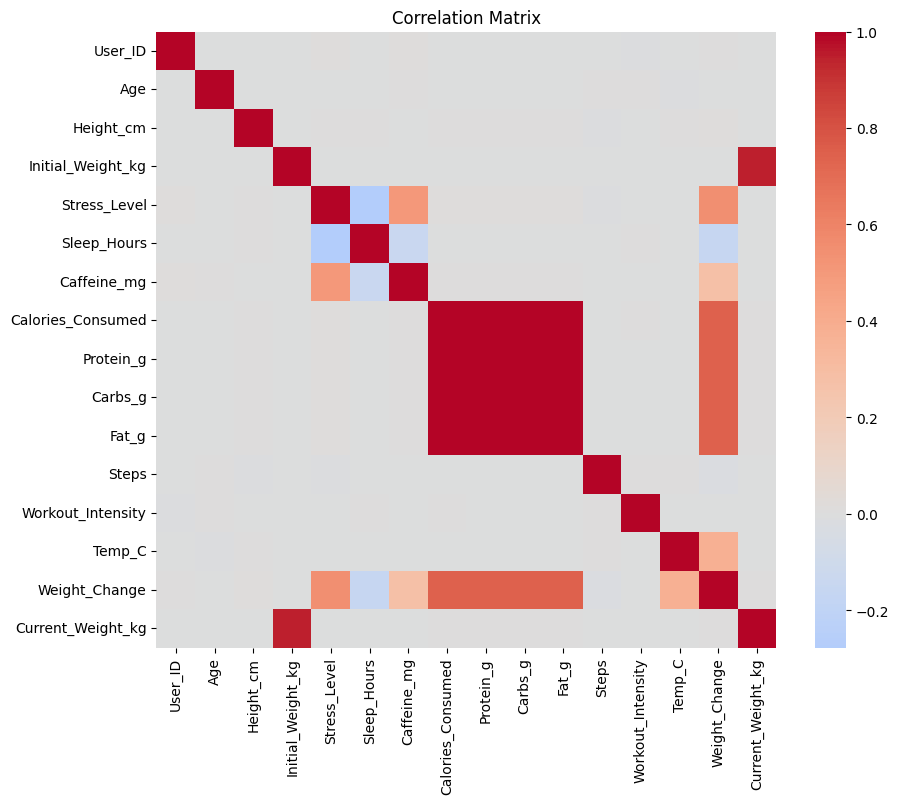

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

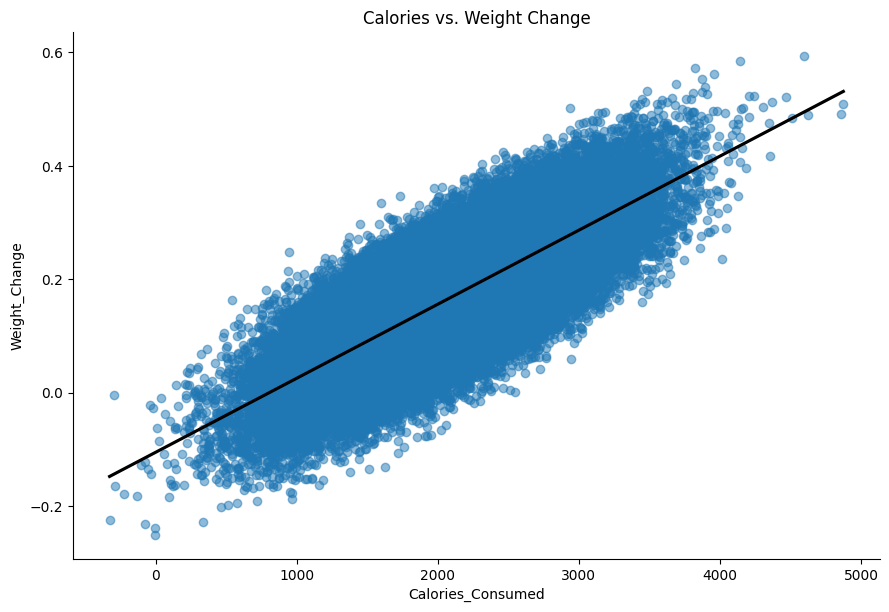

In [7]:
sns.lmplot(
    data=df,
    x="Calories_Consumed",
    y="Weight_Change",
    height=6,
    aspect=1.5,
    scatter_kws={"alpha":0.5},
    line_kws={"color":"black"}
)

plt.title("Calories vs. Weight Change")
plt.show()

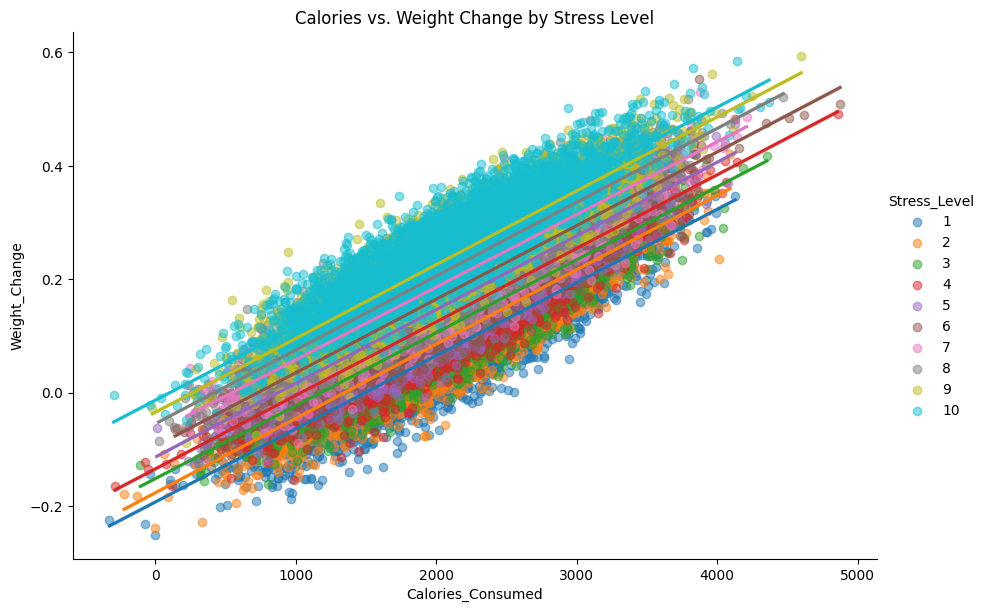

In [8]:
sns.lmplot(
    data=df,
    x="Calories_Consumed",
    y="Weight_Change",
    hue="Stress_Level",
    height=6,
    aspect=1.5,
    scatter_kws={"alpha":0.5},
)

plt.title("Calories vs. Weight Change by Stress Level")
plt.show()

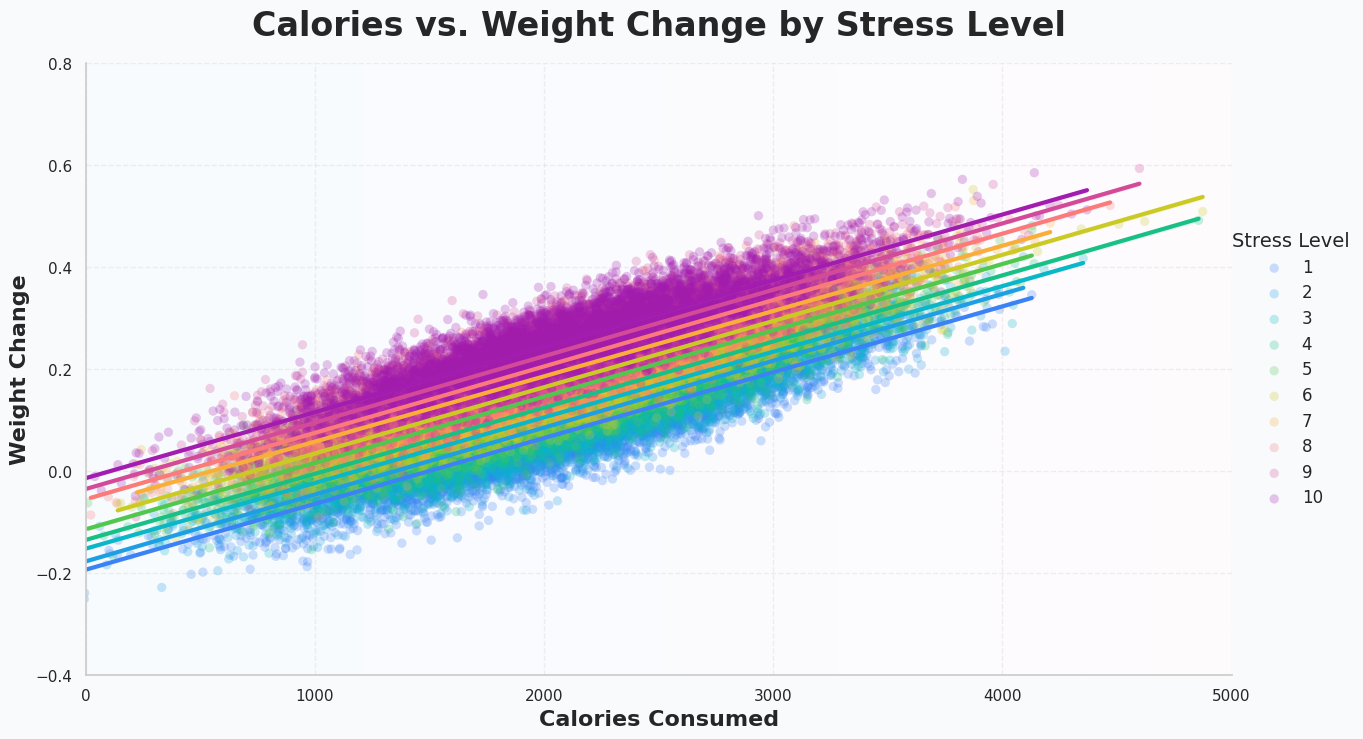

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

# Style
sns.set_theme(style="whitegrid")

# Create custom gradient palette
colors = [
    "#2563eb",  # blue
    "#06b6d4",  # cyan
    "#22c55e",  # green
    "#facc15",  # yellow
    "#fb923c",  # orange
    "#f43f5e",  # pink/red
    "#a21caf"   # purple
]

stress_levels = sorted(df["Stress_Level"].unique())

palette = sns.color_palette("blend:#3b82f6,#06b6d4,#22c55e,#facc15,#fb7185,#a21caf", 
                            n_colors=len(stress_levels))
# Create plot
g = sns.lmplot(
    data=df,
    x="Calories_Consumed",
    y="Weight_Change",
    hue="Stress_Level",
    palette=palette,
    height=7,
    aspect=1.8,
    scatter_kws={
        "alpha": 0.25,
        "s": 45,
        "edgecolor": "none"
    },
    line_kws={
        "linewidth": 3
    }
)

# Figure styling
g.fig.set_facecolor("#f8fafc")

ax = g.ax

# Soft gradient background
gradient = np.linspace(0, 1, 256)
gradient = np.vstack((gradient, gradient))

ax.imshow(
    gradient,
    extent=[0, 5000, -0.4, 0.8],
    aspect='auto',
    cmap=LinearSegmentedColormap.from_list(
        "bg_gradient",
        ["#e0f2fe", "#fdf2f8"]
    ),
    alpha=0.25,
    zorder=0
)

# Labels and title
ax.set_title(
    "Calories vs. Weight Change by Stress Level",
    fontsize=24,
    weight="bold",
    pad=20
)

ax.set_xlabel(
    "Calories Consumed",
    fontsize=16,
    weight="bold"
)

ax.set_ylabel(
    "Weight Change",
    fontsize=16,
    weight="bold"
)

# Grid styling
ax.grid(True, linestyle="--", alpha=0.3)

# Remove top/right spines
sns.despine()

# Legend styling
legend = g._legend
legend.set_title("Stress Level")

for text in legend.get_texts():
    text.set_fontsize(12)

legend.get_title().set_fontsize(14)

plt.show()

It seems like from this dataset, stress, caffeine intake, and ambient temperature have the greatest impact on weight loss besides calories consumed. 

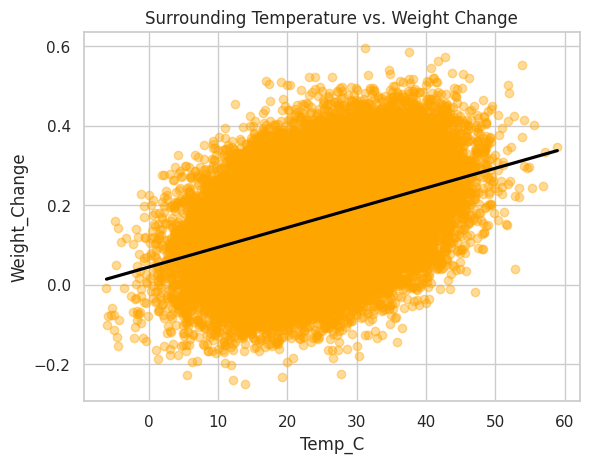

In [10]:
sns.regplot(
    data=df,
    x="Temp_C",
    y="Weight_Change",
    scatter_kws={"alpha":0.4},
    color="orange",
    line_kws={"color":"black"}
)

plt.title("Surrounding Temperature vs. Weight Change")
plt.show()

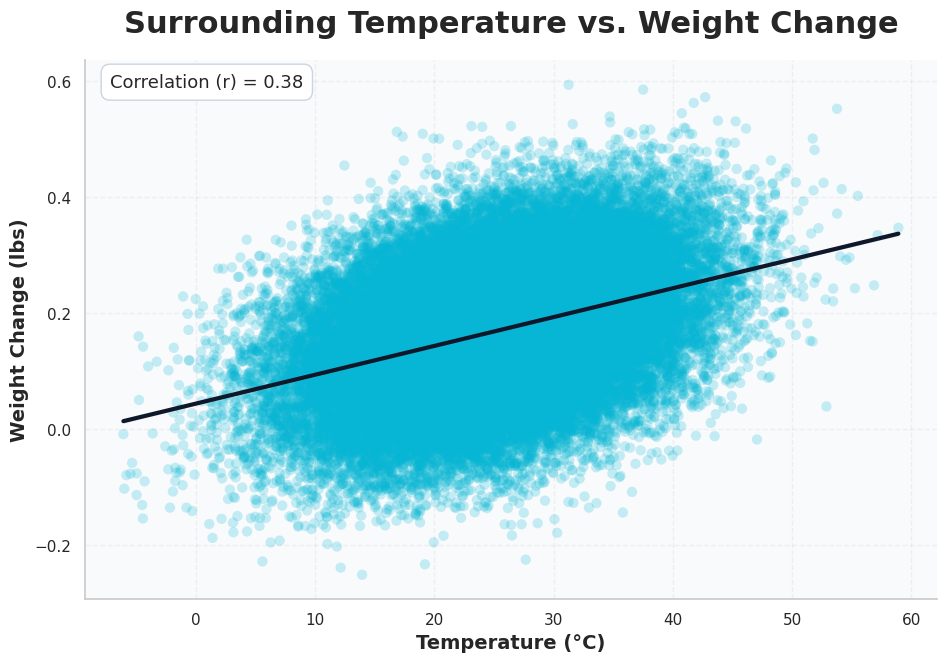

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Calculate correlation
corr = df["Temp_C"].corr(df["Weight_Change"])

# Style
sns.set_theme(style="whitegrid")

# Create figure
plt.figure(figsize=(11, 7))

# Modern regplot
sns.regplot(
    data=df,
    x="Temp_C",
    y="Weight_Change",
    
    scatter_kws={
        "alpha": 0.22,
        "s": 55,
        "color": "#06b6d4",
        "edgecolor": "none"
    },
    
    line_kws={
        "color": "#0f172a",
        "linewidth": 3
    }
)

# Background color
plt.gca().set_facecolor("#f8fafc")

# Title + subtitle
plt.title(
    "Surrounding Temperature vs. Weight Change",
    fontsize=22,
    weight="bold",
    pad=20
)

# Axis labels
plt.xlabel(
    "Temperature (°C)",
    fontsize=14,
    weight="bold"
)

plt.ylabel(
    "Weight Change (lbs)",
    fontsize=14,
    weight="bold"
)

# Add correlation annotation
plt.text(
    0.03,
    0.95,
    f"Correlation (r) = {corr:.2f}",
    transform=plt.gca().transAxes,
    fontsize=13,
    bbox=dict(
        facecolor="white",
        edgecolor="#cbd5e1",
        boxstyle="round,pad=0.5"
    )
)

# Grid styling
plt.grid(alpha=0.25, linestyle="--")

# Remove extra borders
sns.despine()

plt.show()

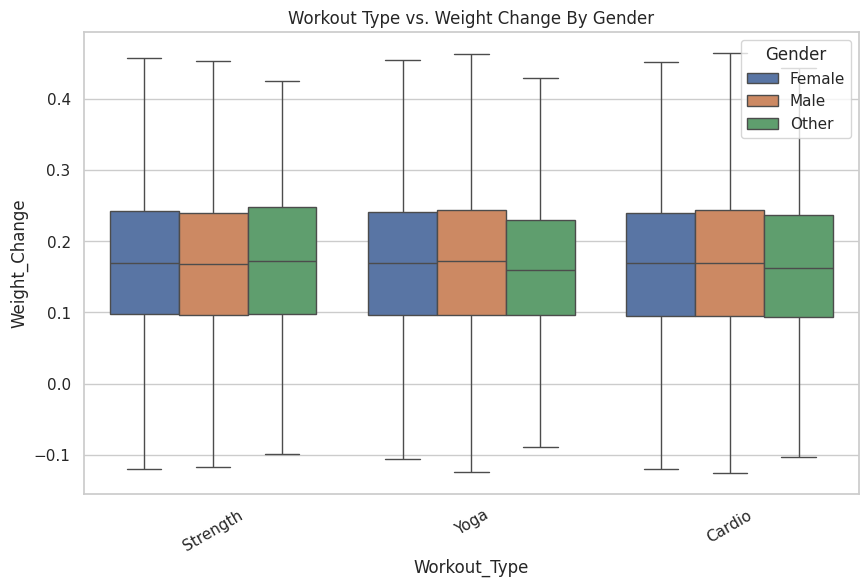

In [12]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Workout_Type",
    y="Weight_Change",
    hue="Gender",
    showfliers=False
)

plt.title("Workout Type vs. Weight Change By Gender")
plt.xticks(rotation=30)
plt.show()

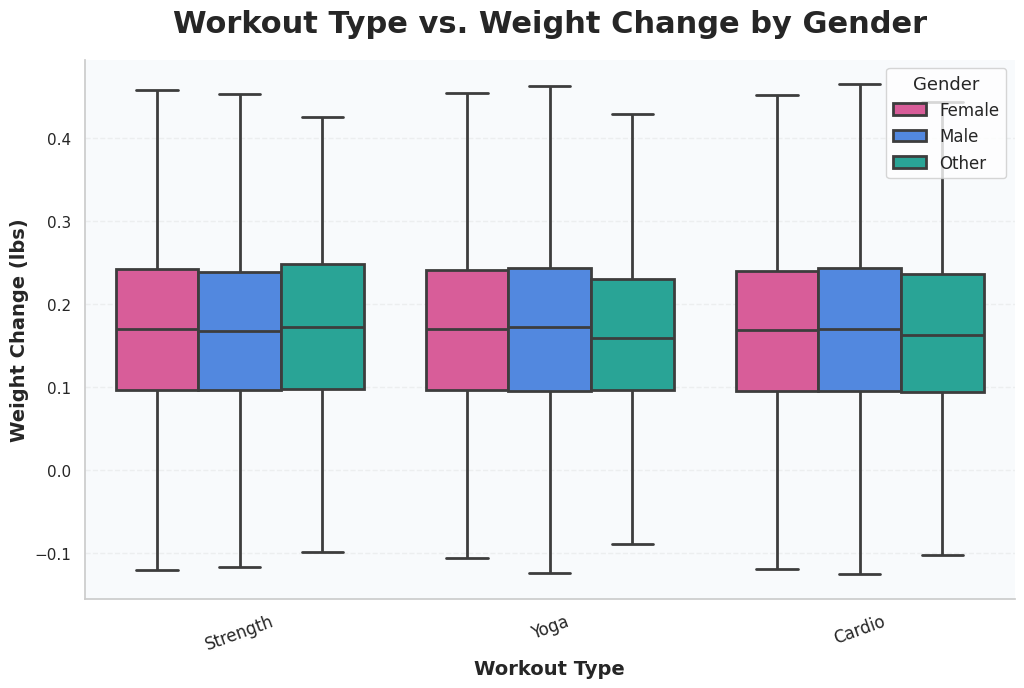

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Modern style
sns.set_theme(style="whitegrid")

# Create figure
plt.figure(figsize=(12, 7))

# Prettier palette
palette = {
    "Male": "#3b82f6",      # blue
    "Female": "#ec4899",    # pink
    "Other": "#14b8a6"      # teal
}

# Boxplot
sns.boxplot(
    data=df,
    x="Workout_Type",
    y="Weight_Change",
    hue="Gender",
    palette=palette,
    showfliers=False,
    linewidth=2
)

# Title
plt.title(
    "Workout Type vs. Weight Change by Gender",
    fontsize=22,
    weight="bold",
    pad=20
)

# Axis labels with units
plt.xlabel(
    "Workout Type",
    fontsize=14,
    weight="bold"
)

plt.ylabel(
    "Weight Change (lbs)",
    fontsize=14,
    weight="bold"
)

# Rename x-axis category labels
new_labels = [
    "Strength",
    "Yoga",
    "Cardio",
]

plt.xticks(
    ticks=range(len(new_labels)),
    labels=new_labels,
    rotation=20,
    fontsize=12
)

# Legend title
plt.legend(
    title="Gender",
    fontsize=12,
    title_fontsize=13
)

# Background styling
plt.gca().set_facecolor("#f8fafc")

# Grid styling
plt.grid(axis="y", alpha=0.25, linestyle="--")

# Remove extra borders
sns.despine()

plt.show()

In [14]:
df.head()

,User_ID,Age,Gender,Height_cm,Initial_Weight_kg,Stress_Level,Sleep_Hours,Caffeine_mg,Calories_Consumed,Protein_g,Carbs_g,Fat_g,Steps,Workout_Type,Workout_Intensity,Temp_C,Weight_Change,Current_Weight_kg
0,275,23,Female,169.355325,111.485330,10,7.016453,211.426469,2801.764291,175.1,315.2,93.4,8172,Strength,6,18.823955,0.317158,111.802488
1,296,43,Female,174.424939,109.699334,1,7.320227,211.979739,2666.001616,166.6,299.9,88.9,7988,NaN,0,36.987432,0.211877,109.911211
2,125,47,Male,163.246320,110.960286,3,7.238641,160.400067,1707.084012,106.7,192.0,56.9,7976,Yoga,10,35.977033,0.122390,111.082676
3,167,42,Female,164.997333,85.546097,7,5.060697,301.629856,2647.458547,165.5,297.8,88.2,8203,Cardio,10,33.141805,0.308449,85.854547
4,311,54,Male,167.696168,135.710505,5,9.866791,335.199126,2036.567163,127.3,229.1,67.9,8024,NaN,0,19.065076,0.120221,135.830726
